Exploratory Data Analysis (EDA)

2.1 Data Cleaning and Preparation done prevous capstone on data wrangling 

Before analysis, the U.S. Accidents (2016–2023) dataset is preprocessed to ensure data quality and consistency:

•	Missing values in weather and road condition variables are handled using imputation or removal where appropriate.

•	Date-Time features are converted to Python datetime format.

•	New temporal features are engineered, including hour of day, day of week, and month, to capture traffic patterns.

•	Categorical variables such as Weather_Condition, Sunrise_Sunset, and Road_Condition are encoded for analysis.

•	The target variable Severity is treated as an ordinal categorical variable representing crash impact level.


In [1]:
# Import relevant libraries and packages.
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns # For all our visualization needs.
import statsmodels.api as sm 
from statsmodels.graphics.api import abline_plot 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import train_test_split 
from sklearn import linear_model, preprocessing 
import warnings 
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

In [14]:
# Load the data. 
data_us = pd.read_csv("us_accidents_clean.csv")

In [15]:
# Check out its appearance. 
data_us.head()

,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,City,County,State,Distance(mi),Weather_Condition,...,Wind_Speed(mph),Pressure(in),Sunrise_Sunset,Year,Month,DayOfWeek,Hour,DurationHrs,Is_Day,Weather_Simple
0,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,Dayton,Montgomery,OH,0.01,Light Rain,...,6.9,29.68,Night,2016,2,0,5,5.233333,0,Rain
1,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,0.01,Light Rain,...,6.9,29.65,Night,2016,2,0,6,0.500000,0,Rain
2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,Williamsburg,Clermont,OH,0.01,Overcast,...,3.5,29.67,Night,2016,2,0,6,0.500000,0,Cloudy
3,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,Dayton,Montgomery,OH,0.01,Mostly Cloudy,...,4.6,29.64,Night,2016,2,0,7,0.500000,0,Cloudy
4,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,Dayton,Montgomery,OH,0.01,Mostly Cloudy,...,3.5,29.65,Day,2016,2,0,7,0.500000,1,Cloudy


In [16]:
# Another very useful method to call on a recently imported dataset is .info(). Call it here to get a good
# overview of the data
print(data_us.shape)
#print(data_us.columns)
#print(data_us.dtypes)
data_us.info()

(100000, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Severity           100000 non-null  int64  
 1   Start_Time         100000 non-null  object 
 2   End_Time           100000 non-null  object 
 3   Start_Lat          100000 non-null  float64
 4   Start_Lng          100000 non-null  float64
 5   City               100000 non-null  object 
 6   County             100000 non-null  object 
 7   State              100000 non-null  object 
 8   Distance(mi)       100000 non-null  float64
 9   Weather_Condition  100000 non-null  object 
 10  Temperature(F)     100000 non-null  float64
 11  Humidity(%)        100000 non-null  float64
 12  Visibility(mi)     100000 non-null  float64
 13  Wind_Speed(mph)    100000 non-null  float64
 14  Pressure(in)       100000 non-null  float64
 15  Sunrise_Sunset     100000 non-null  obj

In [17]:
# We should also look more closely at the dimensions of the dataset. 
print("There are:", data_us.shape[0], 'rows.')
print("There are:", data_us.shape[1], 'columns.')

There are: 100000 rows.
There are: 23 columns.


Choosing a dependent variable

We now need to pick a dependent variable for our regression analysis: a variable whose values we will predict.

'Severity' seems to be as good a candidate as any. Let's check it out. One of the quickest and most informative ways to understand a variable is to make a histogram of it. This gives us an idea of both the center and spread of its values.

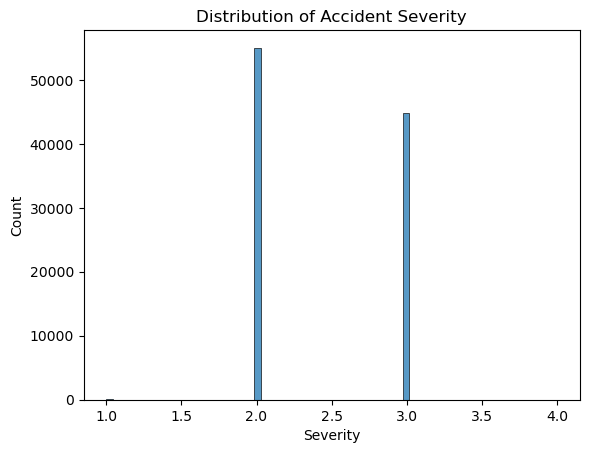

In [21]:
# Making a histogram of the severity variable.
plt.figure()
sns.histplot(data_us["Severity"])
plt.title("Distribution of Accident Severity")
plt.show()

In [22]:
# Get a basic statistical summary of the variable 
print(data_us["Severity"].describe())

count    100000.000000
mean          2.448120
std           0.499931
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max           4.000000
Name: Severity, dtype: float64


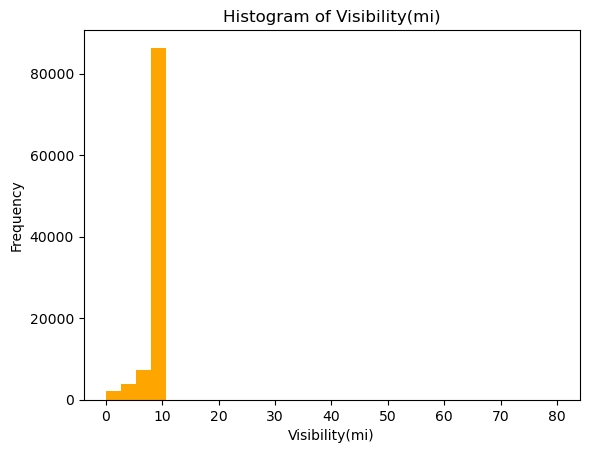

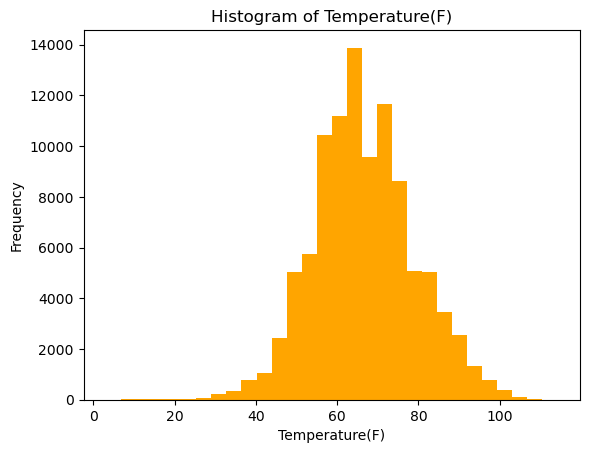

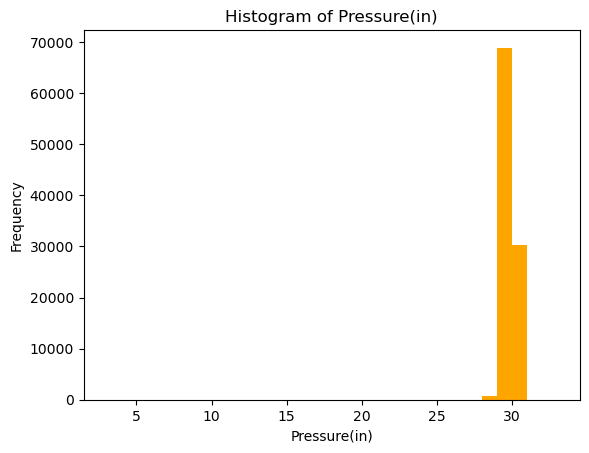

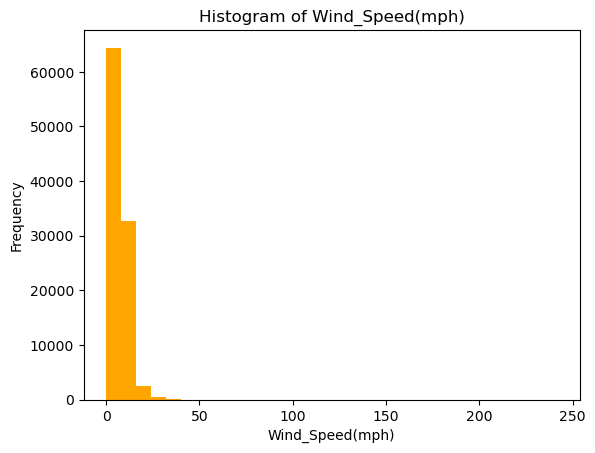

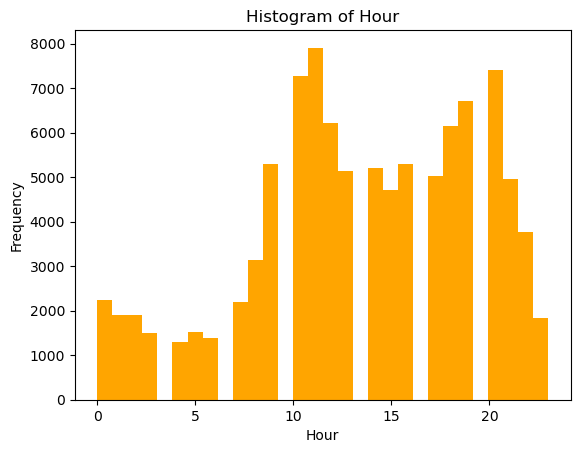

In [25]:
#Numerical Features (Histograms)
num_features = [
    "Visibility(mi)",
    "Temperature(F)",
    "Pressure(in)",
    "Wind_Speed(mph)",
    "Hour"
]

for col in num_features:
    if col in data_us.columns:
        plt.figure()
        plt.hist(data_us[col], bins=30,color='orange')
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()
    else:
        print(f"Skipped {col} (column not found)")

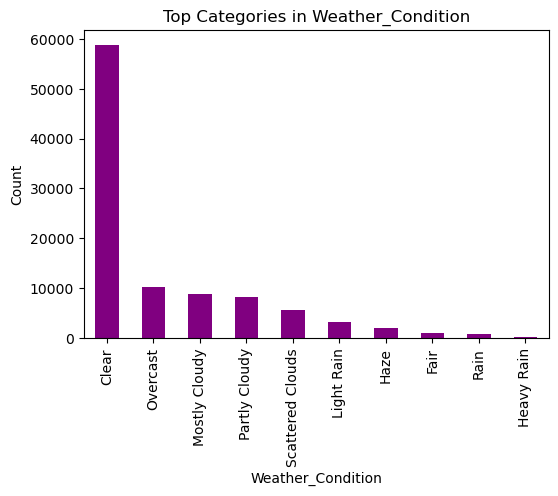

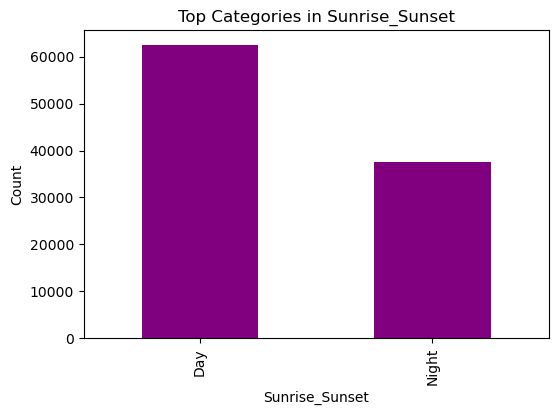

In [32]:
#Categorical Features (Bar Charts)
cat_features = ["Weather_Condition", "Sunrise_Sunset"]

for col in cat_features:
    plt.figure(figsize=(6, 4))
    data_us[col].value_counts().head(10).plot(kind="bar",color='purple')
    plt.title(f"Top Categories in {col}")
    plt.ylabel("Count")
    plt.show()

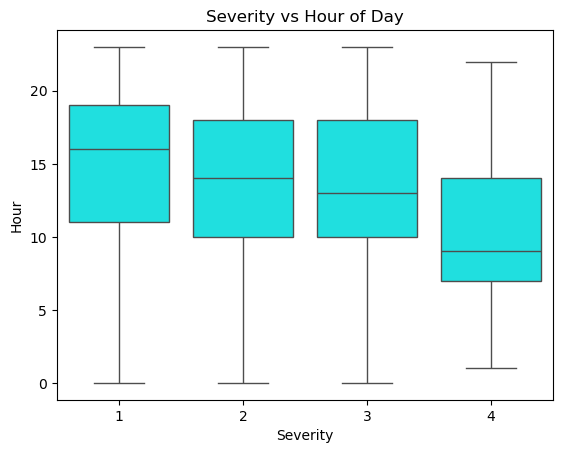

In [35]:
#Severity vs Hour of Day
plt.figure()
sns.boxplot(x="Severity", y="Hour", data=data_us,color='cyan')
plt.title("Severity vs Hour of Day")
plt.show()

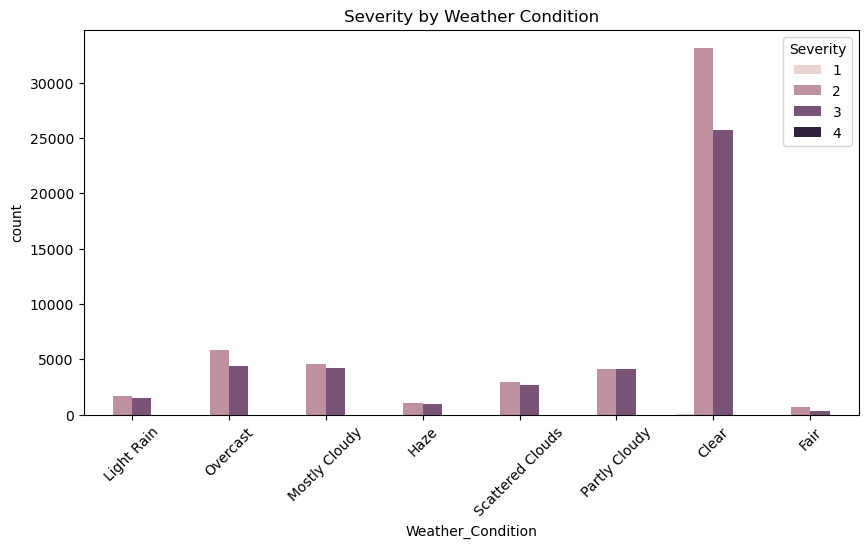

In [36]:
#Severity vs Weather Condition (Top Categories)
top_weather = data_us["Weather_Condition"].value_counts().head(8).index
weather_subset = data_us[data_us["Weather_Condition"].isin(top_weather)]

plt.figure(figsize=(10, 5))
sns.countplot(
    data=weather_subset,
    x="Weather_Condition",
    hue="Severity"
)
plt.xticks(rotation=45)
plt.title("Severity by Weather Condition")
plt.show()

2.2 Univariate Analysis (Feature Distributions)

Each feature is examined individually using histograms, bar charts, and summary statistics to understand its distribution and variability.

•	Accident Severity

A histogram of severity levels shows that most accidents fall into lower severity categories, indicating a clear class imbalance.

•	Time-Based Features

o	Histogram of accident frequency by hour of day reveals peaks during morning and evening rush hours.

o	Bar plots by day of week show higher accident counts on weekdays.

•	Weather Conditions

o	Bar charts of Weather_Condition demonstrate that most crashes occur under clear conditions, though severe accidents are

disproportionately higher during rain, snow, and fog.

•	Visibility and Temperature

o	Histograms of visibility and temperature highlight right-skewed distributions, suggesting increased accident risk under 

low visibility and extreme temperatures

2.3 Bivariate Analysis (Relationships Between Features)

To explore relationships between features and accident severity, bi-plots, box plots, and grouped bar charts are used.

•	Severity vs Time of Day

Box plots show that accidents occurring late at night tend to have higher severity levels.

•	Severity vs Weather Conditions

Grouped bar charts reveal increased proportions of severe accidents during adverse weather conditions (rain, snow, fog).

•	Severity vs Visibility

Scatter plots and bin-based averages demonstrate an inverse relationship between visibility distance and accident severity.

These analyses help identify high-risk combinations of environmental and situational factors.

In [49]:
num_colm =data_us.select_dtypes(include=["float64", "int64"]).columns
print(num_colm)

Index(['Severity', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)',
       'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Pressure(in)',
       'Year', 'Month', 'DayOfWeek', 'Hour', 'DurationHrs', 'Is_Day'],
      dtype='object')


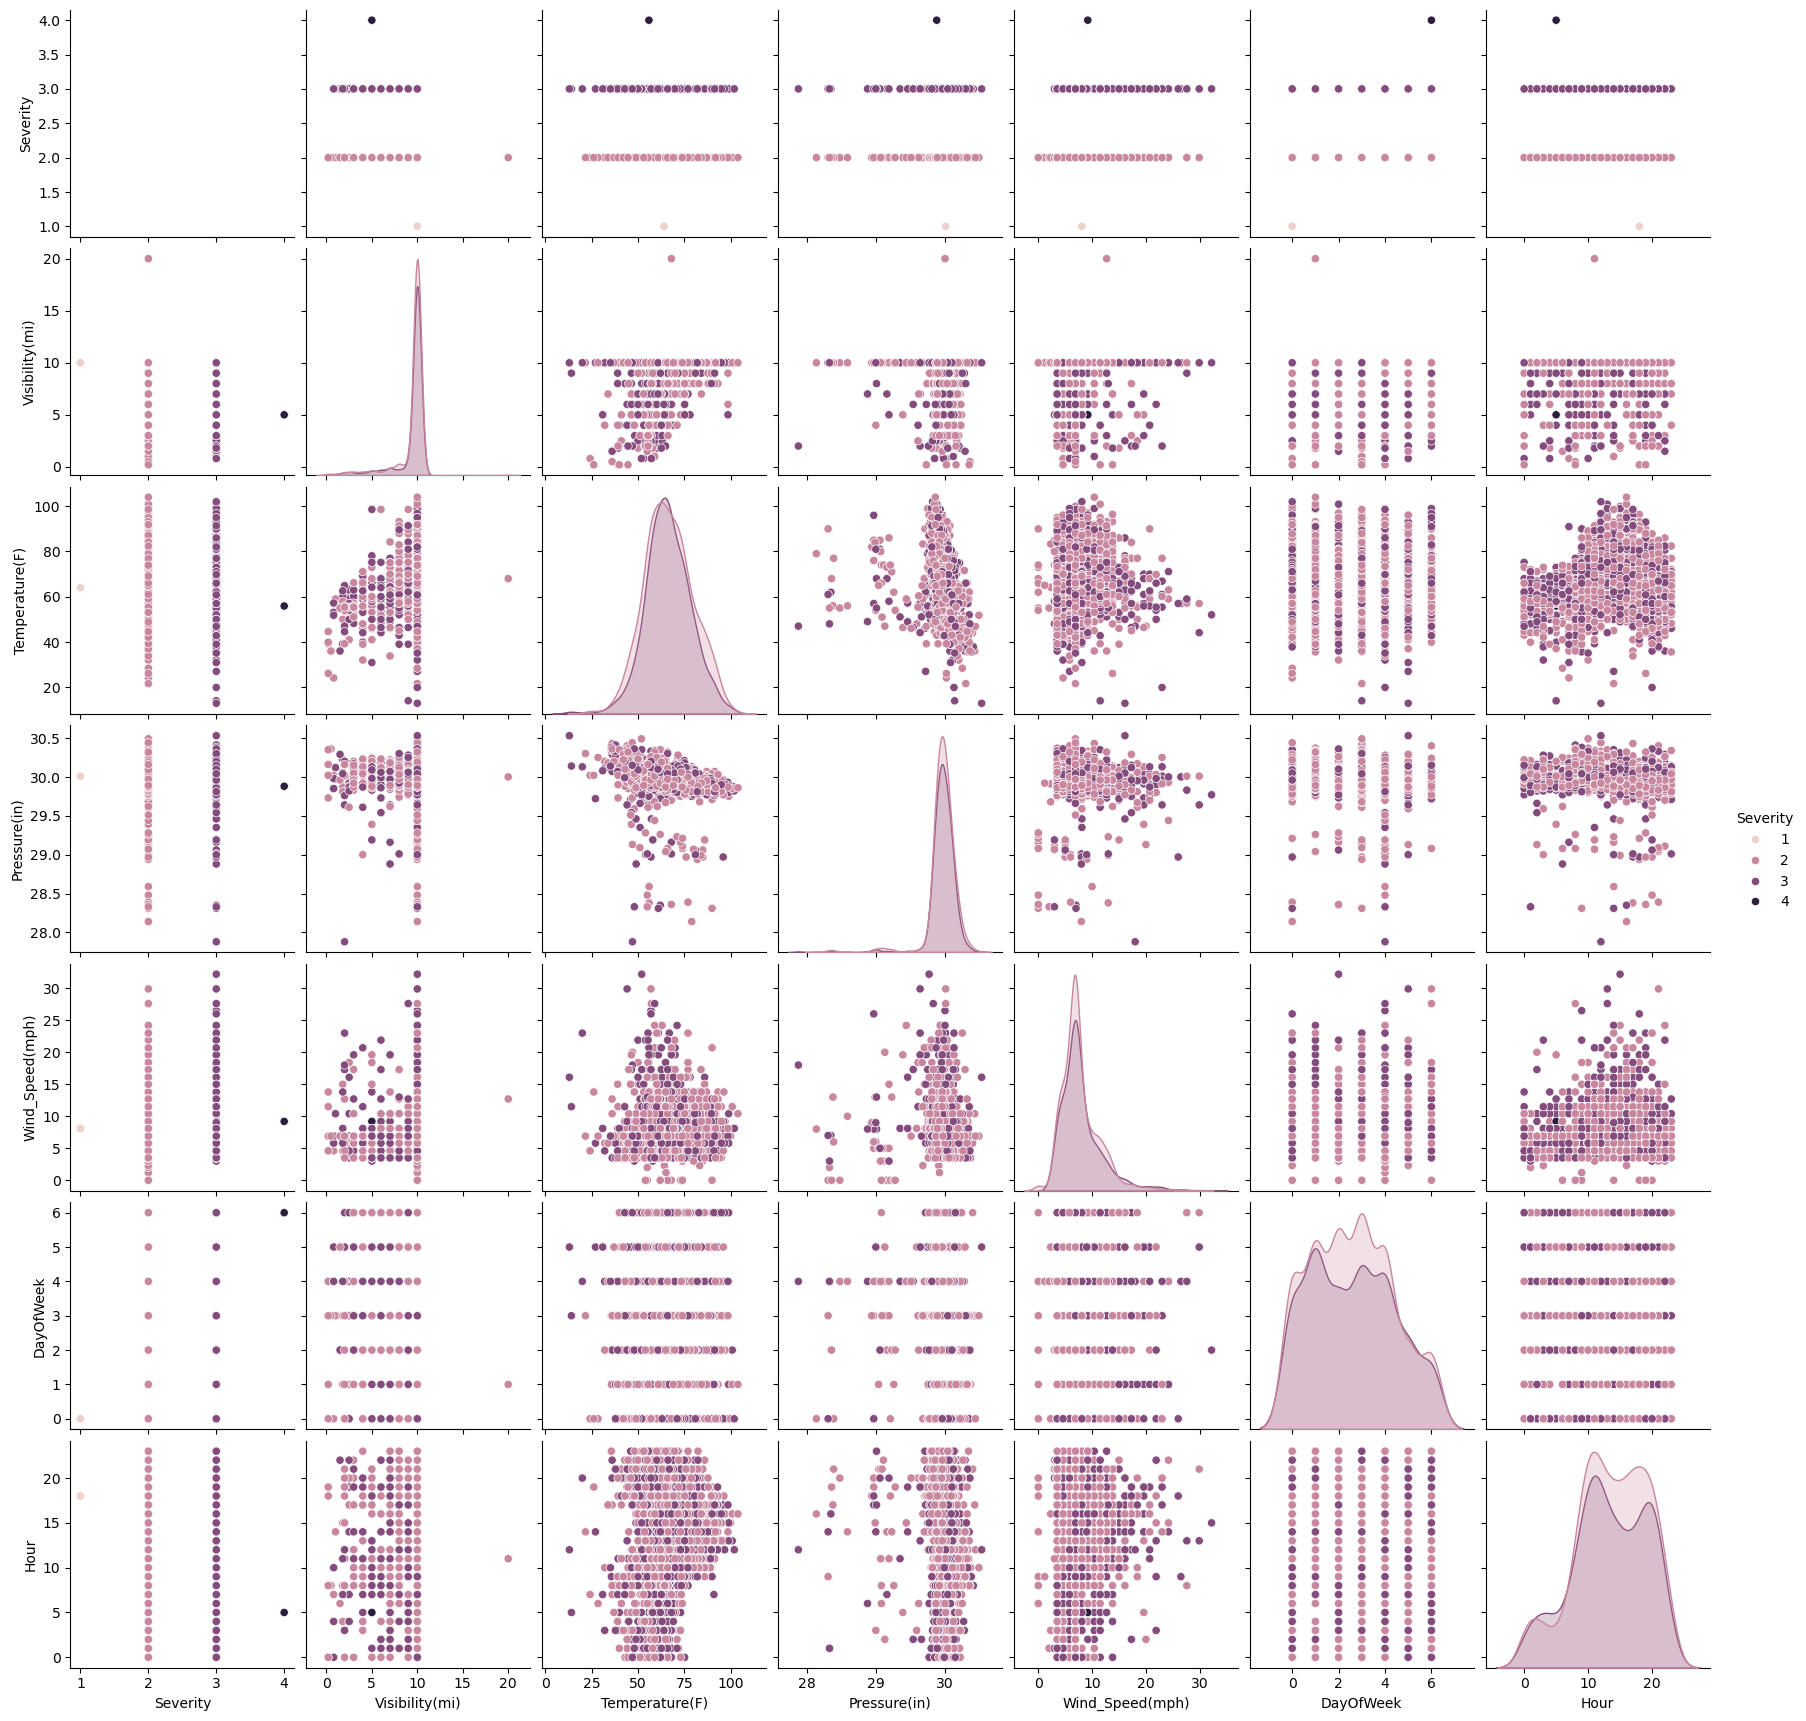

In [56]:
# Make a pairplot of the  data_us

corr_features = [ "Severity", "Visibility(mi)", "Temperature(F)", "Pressure(in)", "Wind_Speed(mph)", 'DayOfWeek', "Hour"] 

sns.pairplot(data_us.sample(2000, random_state=42),vars = corr_features  , hue="Severity")
plt.show()

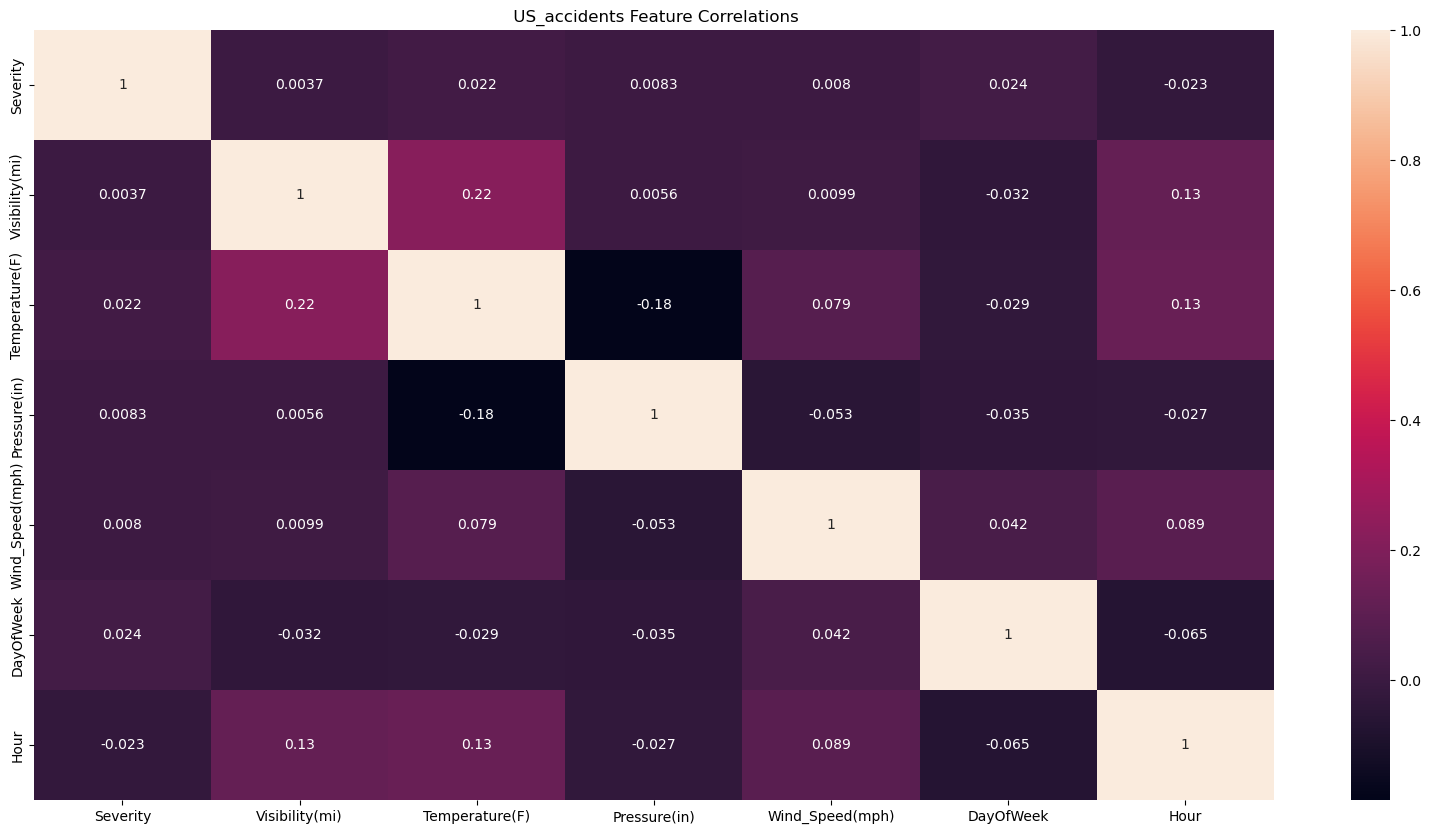

In [60]:
plt.figure(figsize=(20,10))

sns.heatmap(data_us[corr_features].corr(), annot=True)
plt.title(" US_accidents Feature Correlations")
plt.show()

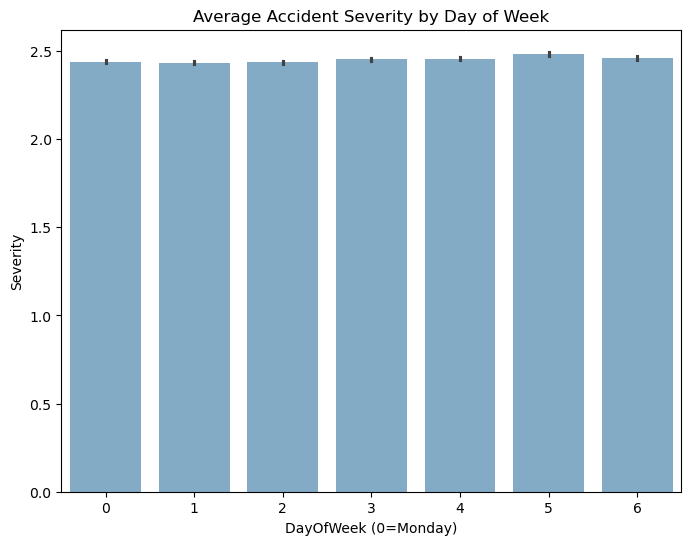

In [67]:
# Plot density against fixed.acidity
plt.figure(figsize=(8,6))
sns.barplot(x='DayOfWeek', y='Severity', data=data_us, alpha=0.6,errorbar='ci')
plt.title("Average Accident Severity by Day of Week")
plt.xlabel("DayOfWeek (0=Monday)")
plt.ylabel("Severity")
plt.show()


2.4 Correlation and Statistical Analysis

To quantify statistical relationships:
•	Pearson correlation coefficients are computed for numerical variables such as:

o	Visibility

o	Temperature

o	Wind speed

o	Distance affected by accident

Results indicate:
•	A negative correlation between visibility and severity.

•	Weak to moderate correlations between accident severity and weather-related variables.

•	Minimal linear correlation with temperature, suggesting non-linear effects.

